In [37]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


In [38]:

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.5,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [39]:
from pydantic import BaseModel, Field
from typing import List, TypedDict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


In [40]:

# class for llm response of task list
class llm_schema(BaseModel):
    task_list: List[str] = Field(..., description="List of tasks generated by the LLM")

# class for graph schema
class GraphSchema(TypedDict):
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

In [41]:

llm_with_schema= llm.with_structured_output(llm_schema)
llm_response = llm_with_schema.invoke("What are the steps to make a cup of tea?")
print(llm_response.task_list)

['Boil fresh water in a kettle', 'Place a tea bag or loose tea in a cup', 'Pour the hot water over the tea', 'Allow the tea to steep for 3 to 5 minutes', 'Remove the tea bag or strain the loose tea', 'Add milk, sugar, or lemon according to your preference', 'Stir gently and serve']


In [42]:
# orchestrator worker function
def orchestrator_node(state: GraphSchema):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an orchestrator. Split the user query into small executable tasks."),
        ("user", "User query: {query}")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"query": state["query"]})

    return {
        "tasks": response.task_list
    }

# example usage
initial_state = GraphSchema(tasks=[], query="What are the steps to make a cup of tea?", results=[], summary="")
updated_state = orchestrator_node(initial_state)
print(updated_state)
    

{'tasks': ['Boil fresh water in a kettle', 'Place a tea bag or loose tea leaves into a cup or teapot', 'Pour the boiling water over the tea', 'Allow the tea to steep for the recommended time based on the variety', 'Remove the tea bag or strain the leaves', 'Add milk, sugar, or lemon to taste if desired', 'Stir the tea and serve']}


In [ ]:
def executor_worker(query: str) -> str:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an executor worker. Answer the given task clearly."),
        ("user", "{query}")
    ])

    chain = prompt | llm | StrOutputParser()
    return chain.invoke({"query": query})

executor_response = executor_worker("What are the steps to make a cup of tea?")
print(executor_response)


To make a standard cup of tea, follow these steps:

### 1. Boil the water
Fill a kettle with fresh, cold water and bring it to a boil. 
*   **Pro-tip:** If you are making green or white tea, let the water sit for a minute after boiling so it isn't scorching hot, which can make those teas taste bitter. Black and herbal teas generally prefer water at a full rolling boil.

### 2. Prepare your cup
Place your tea bag or a tea infuser containing loose-leaf tea into your mug.

### 3. Pour the water
Pour the hot water directly over the tea bag or leaves. This helps to agitate the tea and release the flavor.

### 4. Steep
Let the tea sit (steep) for the appropriate amount of time:
*   **Green/White tea:** 2–3 minutes.
*   **Black tea:** 3–5 minutes.
*   **Herbal tea:** 5–7 minutes (or longer for a stronger flavor).

### 5. Remove the tea
Remove the tea bag or infuser. Be careful not to squeeze the tea bag too hard, as this can release tannins that make the tea taste overly bitter.

### 6. Custo

In [44]:
# collector node function
from concurrent.futures import ThreadPoolExecutor

def collector_node(state: GraphSchema):
    tasks = state["tasks"]

    if not tasks:
        return {"results": []}

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        results = list(executor.map(executor_worker, tasks))

    return {
        "results": results
    }

In [45]:
def summarizer_node(state: GraphSchema):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a summarizer. Combine the results into one clear final answer."),
        ("user", "Results:\n{results}")
    ])

    chain = prompt | llm | StrOutputParser()
    summary = chain.invoke({
        "results": "\n\n".join(state["results"])
    })

    return {
        "summary": summary
    }

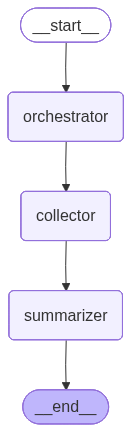

In [49]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(GraphSchema)

graph_builder.add_node("orchestrator", orchestrator_node)
graph_builder.add_node("collector", collector_node)
graph_builder.add_node("summarizer", summarizer_node)

graph_builder.add_edge(START, "orchestrator")
graph_builder.add_edge("orchestrator", "collector")
graph_builder.add_edge("collector", "summarizer")
graph_builder.add_edge("summarizer", END)

graph = graph_builder.compile()

graph_builder.compile()
#compile the graph


In [50]:
for chunk in graph.stream(
          {"tasks": [], 
            "query": "What are the steps to make a cup of tea and what are the benefits of drinking tea?", 
            "results": [], "summary": ""},
    stream_mode="updates"
):
    print(chunk)

{'orchestrator': {'tasks': ['Identify the steps to prepare a cup of tea', 'Research the health benefits of drinking tea', 'Synthesize the steps and benefits into a clear response']}}
{'collector': {'results': ["To prepare a standard cup of tea, follow these steps:\n\n### 1. Gather Your Supplies\n*   **Fresh water** (cold, filtered water is best).\n*   **Tea** (a tea bag or loose-leaf tea).\n*   **A kettle** (stovetop or electric).\n*   **A mug or teacup**.\n*   **Optional add-ins:** Sugar, honey, milk, lemon, or sweeteners.\n\n### 2. Boil the Water\nFill your kettle with fresh water and heat it. \n*   **Note:** If using green or white tea, stop just before a rolling boil (around 175°F/80°C). For black tea or herbal tea, bring the water to a full boil (212°F/100°C).\n\n### 3. Prepare the Mug\nPlace your tea bag or a tea infuser containing loose-leaf tea into your mug.\n\n### 4. Steep the Tea\nPour the hot water over the tea. Let it steep according to the type of tea:\n*   **Green/White 